In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Read the data 

df = pd.read_csv('height-weight.csv')

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
df.tail()

,Weight,Height
18,76,150
19,87,167
20,45,129
21,56,140
22,72,160


In [5]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


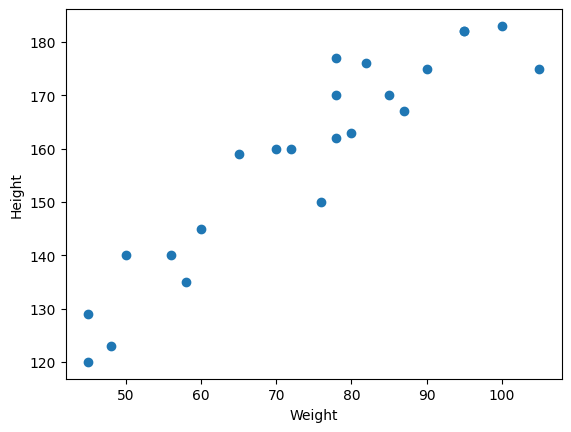

In [6]:
#EDA

plt.scatter(df.Weight , df.Height)
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [7]:
#define X and Y

X= df[['Weight']]
y = df[['Height']]

In [ ]:
# Train - Test split
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test =       train_test_split(X , y , test_size= 0.25 , random_state=1)

In [9]:
X_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [10]:
X_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [11]:
y_train

,Height
10,176
4,160
2,123
18,150
6,163
7,175
1,135
14,170
0,120
15,177


In [12]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [13]:
# Scaling >> Standardization -- (fit-transform use on train data and transform use on test data)

# if you use fit on test data that is wrong because you are doing data leakage , avoid it 

# most of the ml modals standard scaler is used because it deal with normal distribtion 

# scaling is use always after train test split

# traget variable should not be scaled 

# avoid use scaling in cateogrical feature

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train) # for train data use fit_transform  

X_test = scaler.transform(X_test) # for test data use transform 


In [17]:
# model training 

from sklearn.linear_model import LinearRegression

Regressor = LinearRegression()

Regressor

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
Regressor.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[17.73]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[160.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [19]:
Regressor.intercept_

array([160.])

In [20]:
Regressor.coef_


array([[17.7307072]])

In [21]:
print('Intercept of the model is ', Regressor.intercept_ )
print('coefficient  of the model is ', Regressor.coef_)


Intercept of the model is  [160.]
coefficient  of the model is  [[17.7307072]]


In [22]:
# prediction on Train data 
# interpretion of coef >> If one unit increase of weight , on an average height is increase by 17.73 units
# predicted height of (y ) on X_test = 160 + 17.73*(X_test)

In [23]:
#prediction on train data 
Regressor.predict(X_train)

array([[166.65863288],
       [153.47066096],
       [129.29271243],
       [160.06464692],
       [164.46063756],
       [175.45061417],
       [140.28268904],
       [169.95562586],
       [125.99571945],
       [162.26264224],
       [155.66865628],
       [138.08469371],
       [162.26264224],
       [180.94560247],
       [191.93557907],
       [180.94560247],
       [162.26264224]])

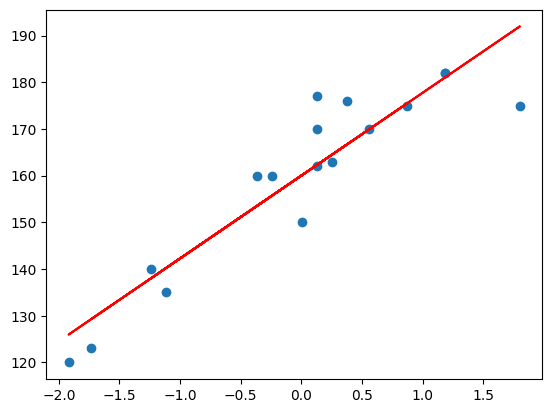

In [24]:
plt.scatter(X_train , y_train)
plt.plot(X_train , Regressor.predict(X_train) , 'r')

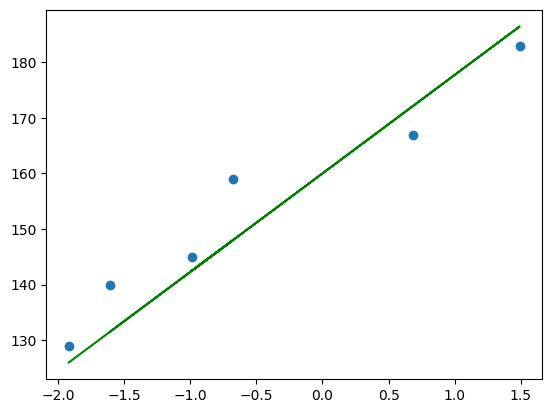

In [25]:
#predection on test data 
y_pred_test = Regressor.predict(X_test)

plt.scatter(X_test , y_test)
plt.plot(X_test , y_pred_test , 'g')

In [27]:
#performance metrics  

from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [29]:
mean_absolute_error( y_test , y_pred_test )

5.608571289304838

In [30]:
mean_squared_error(  y_test , y_pred_test)

41.285662830455514

In [33]:
rsq = r2_score( y_test , y_pred_test)

In [ ]:
#adjusted rsquare 
#adjusted R2 = [1-(1-rsquare)*n-1 / (n-k-1) ] # n is no of observation and k is no of predictor variables

In [35]:
[1-(1-rsq)*(len(y_test)-1) / (len(y_test)- X_test.shape[1]-1)]

[0.8401295217820757]

In [36]:
#assumption 
# x-y Should have linear relationship
# observation should have no relation
# error should have constant variation 
# error shoulf be normally distributed 
# feature among themself should be least related 


In [39]:
# error should have constant variation 
# error shoulf be normally distributed 

Error = y_test - y_pred_test
Error

,Height
20,3.004281
17,11.024327
3,2.519316
13,-3.440591
19,-5.153621
16,8.509292


C:\Users\DELL\AppData\Local\Temp\ipykernel_18624\1635436644.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Error)


<Axes: ylabel='Density'>

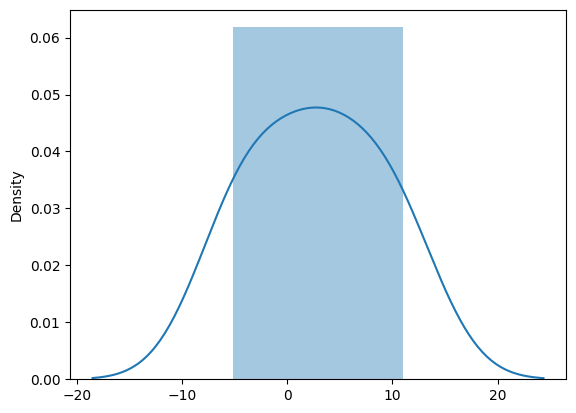

In [46]:
sns.distplot(Error) 
# nearly it is normally distribution plot